In [1]:
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
from PIL import Image


COLORMAP = [
    (0.0, 0.0, 0.0),
    (174.0, 199.0, 232.0),
    (152.0, 223.0, 138.0),
    (31.0, 119.0, 180.0),
    (255.0, 187.0, 120.0),
    (188.0, 189.0, 34.0),
    (140.0, 86.0, 75.0),
    (255.0, 152.0, 150.0),
    (214.0, 39.0, 40.0),
    (197.0, 176.0, 213.0),
    (148.0, 103.0, 189.0),
    (196.0, 156.0, 148.0),
    (23.0, 190.0, 207.0),
    (247.0, 182.0, 210.0),
    (219.0, 219.0, 141.0),
    (255.0, 127.0, 14.0),
    (158.0, 218.0, 229.0),
    (44.0, 160.0, 44.0),
    (112.0, 128.0, 144.0),
    (227.0, 119.0, 194.0),
    (213.0, 92.0, 176.0),
    (94.0, 106.0, 211.0),
    (82.0, 84.0, 163.0),
    (100.0, 85.0, 144.0),
    (66.0, 188.0, 102.0),
    (140.0, 57.0, 197.0),
    (202.0, 185.0, 52.0),
    (51.0, 176.0, 203.0),
    (200.0, 54.0, 131.0),
    (92.0, 193.0, 61.0),
    (78.0, 71.0, 183.0),
    (172.0, 114.0, 82.0),
    (91.0, 163.0, 138.0),
    (153.0, 98.0, 156.0),
    (140.0, 153.0, 101.0),
    (100.0, 125.0, 154.0),
    (178.0, 127.0, 135.0),
    (146.0, 111.0, 194.0),
    (96.0, 207.0, 209.0),
]

PixelJson = Dict[str, List[int]]


def load_pixel_json(path: str) -> PixelJson:
    p = Path(path)
    if not p.is_file():
        raise FileNotFoundError(f"JSON file not found: {p}")
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError(f"Top-level JSON must be a dict, got {type(data)}")
    return data


def infer_num_classes_from_pixels(*dicts: PixelJson) -> int:
    max_cls = -1
    for d in dicts:
        for img_id, pixels in d.items():
            if not isinstance(pixels, list):
                raise ValueError(f"Value for image '{img_id}' must be a list of class indices")
            if not pixels:
                continue
            arr = np.asarray(pixels, dtype=np.int64)
            local_max = int(arr.max())
            if local_max > max_cls:
                max_cls = local_max
    if max_cls < 0:
        raise ValueError("Could not infer num_classes: no pixel class indices found in JSONs")
    return max_cls + 1


def compute_confusion_matrix(
    preds: np.ndarray, gts: np.ndarray, num_classes: int
) -> np.ndarray:
    """Compute confusion matrix of shape (num_classes, num_classes).
    Rows: GT, Columns: Pred.
    """
    assert preds.shape == gts.shape
    mask = (gts >= 0) & (gts < num_classes)
    preds = preds[mask]
    gts = gts[mask]

    if preds.size == 0:
        return np.zeros((num_classes, num_classes), dtype=np.int64)

    idx = gts * num_classes + preds
    conf = np.bincount(idx, minlength=num_classes * num_classes).reshape(
        num_classes, num_classes
    )
    return conf.astype(np.int64)


def compute_metrics(confusion: np.ndarray) -> dict:
    """confusion: (num_classes, num_classes) GT x Pred
    Returns dict with per-class and mean IoU / accuracy.
    """
    num_classes = confusion.shape[0]
    tp = np.diag(confusion).astype(np.float64)
    gt_sum = confusion.sum(axis=1).astype(np.float64)  # per-class GT
    pred_sum = confusion.sum(axis=0).astype(np.float64)  # per-class Pred
    union = gt_sum + pred_sum - tp

    iou = np.zeros(num_classes, dtype=np.float64)
    acc = np.zeros(num_classes, dtype=np.float64)

    valid_iou = union > 0
    iou[valid_iou] = tp[valid_iou] / union[valid_iou]

    valid_acc = gt_sum > 0
    acc[valid_acc] = tp[valid_acc] / gt_sum[valid_acc]

    miou = iou[valid_iou].mean() if valid_iou.any() else 0.0
    macc = acc[valid_acc].mean() if valid_acc.any() else 0.0
    pix_acc = tp.sum() / confusion.sum() if confusion.sum() > 0 else 0.0

    return {
        "per_class_iou": iou,
        "per_class_acc": acc,
        "miou": miou,
        "macc": macc,
        "pix_acc": pix_acc,
    }


def class_to_rgb(mask_class: np.ndarray, colormap: np.ndarray) -> np.ndarray:
    """Convert class index mask (H, W) back to an RGB image (H, W, 3) using colormap."""
    return colormap[mask_class.astype(np.int64)]



In [2]:
def validate_pixels(
    gt: PixelJson,
    pred: PixelJson,
    height: int,
    width: int,
    num_classes: int,
) -> Tuple[dict, np.ndarray]:
    gt_ids = set(gt.keys())
    pred_ids = set(pred.keys())
    common_ids = sorted(gt_ids & pred_ids)
    missing_in_pred = sorted(gt_ids - pred_ids)
    missing_in_gt = sorted(pred_ids - gt_ids)

    if not common_ids:
        raise ValueError("No common image IDs between GT and predictions.")

    global_conf = np.zeros((num_classes, num_classes), dtype=np.int64)

    for img_id in common_ids:
        gt_pixels = np.asarray(gt[img_id], dtype=np.int64)
        pred_pixels = np.asarray(pred[img_id], dtype=np.int64)

        if gt_pixels.shape != pred_pixels.shape:
            raise ValueError(
                f"Shape mismatch for image '{img_id}': "
                f"GT len={gt_pixels.size}, Pred len={pred_pixels.size}"
            )
        if gt_pixels.size != height * width:
            raise ValueError(
                f"Unexpected number of pixels for image '{img_id}': "
                f"got {gt_pixels.size}, expected {height * width}"
            )

        gt_flat = gt_pixels.reshape(-1)
        pred_flat = pred_pixels.reshape(-1)

        conf = compute_confusion_matrix(pred_flat, gt_flat, num_classes=num_classes)
        global_conf += conf

    metrics = compute_metrics(global_conf)
    summary = {
        "num_images_gt": len(gt_ids),
        "num_images_pred": len(pred_ids),
        "num_images_common": len(common_ids),
        "num_images_missing_in_pred": len(missing_in_pred),
        "num_images_missing_in_gt": len(missing_in_gt),
        "num_classes": num_classes,
        "pix_acc": float(metrics["pix_acc"]),
        "macc": float(metrics["macc"]),
        "miou": float(metrics["miou"]),
    }

    details = {
        "per_class_iou": metrics["per_class_iou"].tolist(),
        "per_class_acc": metrics["per_class_acc"].tolist(),
        "missing_in_pred": missing_in_pred,
        "missing_in_gt": missing_in_gt,
    }

    return {"summary": summary, "details": details}, global_conf


def visualize_pairs(
    gt: PixelJson,
    pred: PixelJson,
    height: int,
    width: int,
    vis_dir: Path,
) -> None:
    colormap = np.array(COLORMAP, dtype=np.uint8)

    vis_dir.mkdir(parents=True, exist_ok=True)

    gt_ids = set(gt.keys())
    pred_ids = set(pred.keys())
    common_ids = sorted(gt_ids & pred_ids)

    for idx, img_id in enumerate(common_ids):
        gt_pixels = np.asarray(gt[img_id], dtype=np.int64)
        pred_pixels = np.asarray(pred[img_id], dtype=np.int64)

        if gt_pixels.size != height * width or pred_pixels.size != height * width:
            print(
                f"Skipping visualization for '{img_id}' "
                f"due to unexpected pixel count: gt={gt_pixels.size}, pred={pred_pixels.size}"
            )
            continue

        gt_mask = gt_pixels.reshape(height, width)
        pred_mask = pred_pixels.reshape(height, width)

        gt_rgb = class_to_rgb(gt_mask, colormap)
        pred_rgb = class_to_rgb(pred_mask, colormap)

        pair = np.concatenate([gt_rgb, pred_rgb], axis=1)

        # Sanitize filename (replace slashes if img_id contains subdirs)
        safe_id = img_id.replace("/", "_")
        out_path = vis_dir / f"{idx:05d}_{safe_id}.png"
        Image.fromarray(pair.astype(np.uint8)).save(out_path)



In [3]:
# Example usage inside the notebook:

pred_json = "answer_pred_train_image.json"
gt_json = "answer_gt_train_image.json"
height = 144
width = 256
save_details = "train_answer_metrics.json"
vis_dir = Path("viz_answer_train")

gt_data = load_pixel_json(gt_json)
pred_data = load_pixel_json(pred_json)
num_classes = infer_num_classes_from_pixels(gt_data, pred_data)
print(f"num_classes={num_classes}")

metrics, _ = validate_pixels(
    gt=gt_data,
    pred=pred_data,
    height=height,
    width=width,
    num_classes=num_classes,
)

summary = metrics["summary"]
print(f"GT images: {summary['num_images_gt']}, Pred images: {summary['num_images_pred']}, Common: {summary['num_images_common']}")
print(f"Pixel accuracy: {summary['pix_acc']:.4f}")
print(f"Mean accuracy (mAcc): {summary['macc']:.4f}")
print(f"Mean IoU (mIoU): {summary['miou']:.4f}")

with Path(save_details).open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

visualize_pairs(
    gt=gt_data,
    pred=pred_data,
    height=height,
    width=width,
    vis_dir=vis_dir,
)


num_classes=21
GT images: 1000, Pred images: 1000, Common: 1000
Pixel accuracy: 0.1945
Mean accuracy (mAcc): 0.0526
Mean IoU (mIoU): 0.0102


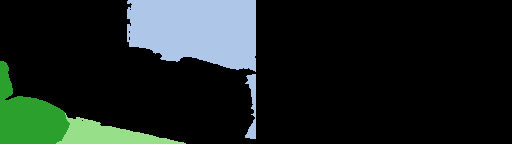

In [6]:
from pathlib import Path
from PIL import Image
from IPython.display import display

vis_dir = Path("viz_answer_train")  # или "vis_answer_image", если нужно
img_path = vis_dir / "00000_00000.png"

img = Image.open(img_path)
display(img)